# Wav2Vec2 + 1D ResNet — AI Voice / Deepfake Audio Detection
SIH PS 26104 — Voice Cloning Detection

**Features in this notebook:**
- wav2vec2 (Indic-capable) backbone + 1D ResNet head with BatchNorm
- Mixed precision (AMP) training for Colab free-tier T4 speed
- Progress bars (tqdm) for batches and epochs
- **Resume training** — safely continue after Colab disconnects
- Training/validation curves saved as PNG + logged in checkpoint
- All metrics logged inside the checkpoint file itself (no separate log file to lose)

Run cells top to bottom. If Colab disconnects mid-training, just re-run all cells —
training will automatically resume from the last saved checkpoint.


## 1. Install dependencies

In [ ]:
!pip install -q transformers soundfile librosa tqdm matplotlib

## 2. Mount Google Drive (checkpoints/logs survive disconnects here)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!cp "/content/drive/MyDrive/indian-deepfake-voice.tar.gz" "/content/"

In [ ]:
!tar -xf "/content/indian-deepfake-voice.tar.gz"

In [ ]:
# !cp -r "/content/drive/MyDrive/sih_voice_clone" "/content/"

!rm -rf "/content/sih_voice_clone"
!cp -r "/content/drive/MyDrive/sih_voice_clone2" "/content/"
!mv "/content/sih_voice_clone2" "/content/sih_voice_clone"

## 3. Imports

In [ ]:
import os
import glob
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import soundfile as sf
import librosa
import matplotlib.pyplot as plt
from transformers import Wav2Vec2FeatureExtractor, Wav2Vec2Model
from tqdm.notebook import tqdm

print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA available: True
GPU: Tesla T4


In [ ]:
from sklearn.metrics import classification_report, accuracy_score
from sklearn.model_selection import train_test_split

## 4. Config

Edit these paths/values for your run. Defaults are tuned for Colab free-tier T4
with a dataset in the low thousands of clips (adjust `num_unfrozen_layers` down
to 0 if you have fewer than ~500 total clips, to avoid overfitting).

In [ ]:
# MODEL_NAME = "facebook/wav2vec2-large-xlsr-53"   # swap to "facebook/wav2vec2-base" if training is too slow
MODEL_NAME = "facebook/wav2vec2-base"
SAMPLE_RATE = 16000
MAX_SECONDS = 4
NUM_SAMPLES = SAMPLE_RATE * MAX_SECONDS
GENUINE_LABEL = 0
SPOOF_LABEL = 1
AUDIO_EXTENSIONS = (".wav", ".flac", ".mp3")

# ---- EDIT THESE ----
dataset_root   = "/content/indian-deepfake-voice"
checkpoint_dir = "/content/sih_voice_clone"
epochs               = 40
batch_size           = 16       # raise to 16 if using wav2vec2-base, keep 4-8 for large-xlsr-53 on T4
lr                   = 2e-5    # Slightly lower LR for deeper fine-tuning
weight_decay         = 1e-4
patience             = 20
num_unfrozen_layers  = 4       # Increased from 2 to 4 to improve accuracy
# ---------------------

os.makedirs(checkpoint_dir, exist_ok=True)
CKPT_LATEST  = os.path.join(checkpoint_dir, "checkpoint_latest.pt")
CKPT_BEST    = os.path.join(checkpoint_dir, "checkpoint_best.pt")
PLOT_PATH    = os.path.join(checkpoint_dir, "training_curves.png")
LOG_CSV_PATH = os.path.join(checkpoint_dir, "training_log.csv")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## 5. Dataset

In [ ]:
class VoiceDataset(Dataset):
    """
    Loads audio files from dataset_root/real/<lang>/*.wav and
    dataset_root/fake/<lang>/*.wav, resamples to 16kHz, and
    pads/crops to a fixed length for batching.
    """

    def __init__(self, split_files):
        self.files = split_files

    def __len__(self):
        return len(self.files)

    def _load_and_fix_length(self, path):
        waveform, orig_sr = sf.read(path, always_2d=False)
        if waveform.ndim > 1:
            waveform = np.mean(waveform, axis=1)
        if orig_sr != SAMPLE_RATE:
            waveform = librosa.resample(waveform, orig_sr=orig_sr, target_sr=SAMPLE_RATE)

        if len(waveform) >= NUM_SAMPLES:
            start = random.randint(0, len(waveform) - NUM_SAMPLES)
            waveform = waveform[start:start + NUM_SAMPLES]
        else:
            num_repeats = int(np.ceil(NUM_SAMPLES / len(waveform)))
            waveform = np.tile(waveform, num_repeats)[:NUM_SAMPLES]

        return waveform.astype(np.float32)

    def __getitem__(self, idx):
        path, label = self.files[idx]
        waveform = self._load_and_fix_length(path)
        return waveform, label


def scan_dataset(dataset_root):
    """Walks dataset_root/real and dataset_root/fake, returns list of (filepath, label)."""
    files = []
    real_root = os.path.join(dataset_root, "real")
    fake_root = os.path.join(dataset_root, "fake")

    for root, label in [(real_root, GENUINE_LABEL), (fake_root, SPOOF_LABEL)]:
        for ext in AUDIO_EXTENSIONS:
            for path in glob.glob(os.path.join(root, "**", f"*{ext}"), recursive=True):
                files.append((path, label))

    random.shuffle(files)
    return files


def build_dataloaders(dataset_root, batch_size=8, val_split=0.15):
    all_files = scan_dataset(dataset_root)
    if len(all_files) == 0:
        raise RuntimeError(f"No audio files found under {dataset_root}. Check folder structure.")

    n_real = sum(1 for _, l in all_files if l == GENUINE_LABEL)
    n_fake = sum(1 for _, l in all_files if l == SPOOF_LABEL)
    print(f"Found {n_real} real files, {n_fake} fake files.")
    if n_real == 0 or n_fake == 0 or max(n_real, n_fake) / max(1, min(n_real, n_fake)) > 3:
        print("WARNING: classes look imbalanced. Consider balancing before training.")

    val_count = max(1, int(len(all_files) * val_split))
    val_files = all_files[:val_count]
    train_files = all_files[val_count:]

    train_ds = VoiceDataset(train_files)
    val_ds = VoiceDataset(val_files)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

    print(f"Train files: {len(train_files)} | Val files: {len(val_files)}")
    return train_loader, val_loader

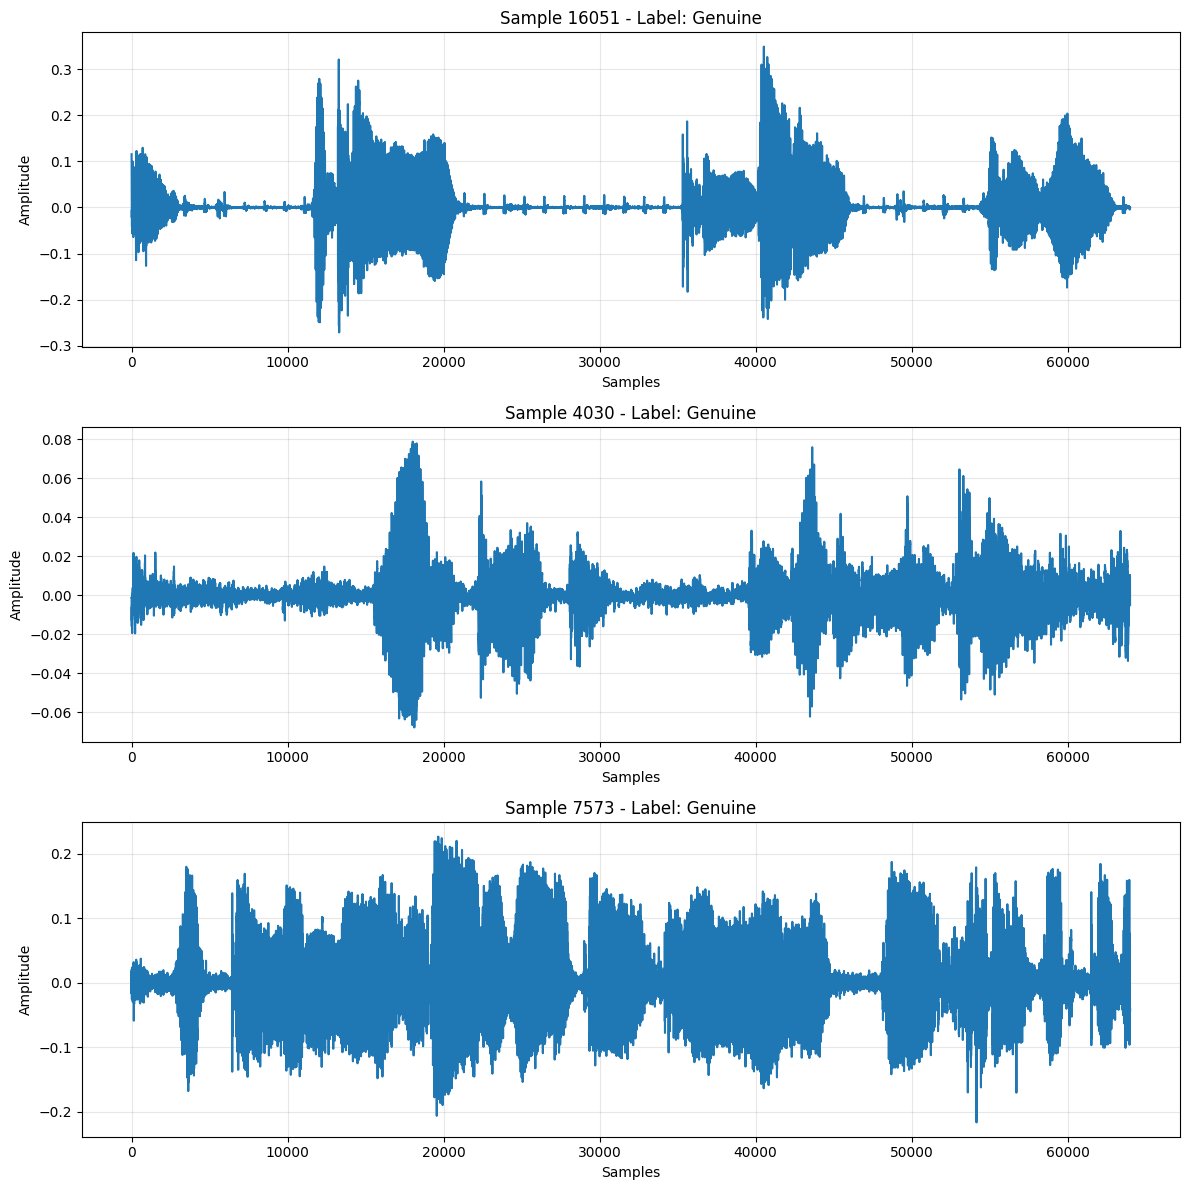

In [ ]:
def visualize_samples(dataset, num_samples=3):
    fig, axes = plt.subplots(num_samples, 1, figsize=(12, 4 * num_samples))
    if num_samples == 1:
        axes = [axes]

    # Get some random indices
    indices = random.sample(range(len(dataset)), num_samples)

    for i, idx in enumerate(indices):
        waveform, label = dataset[idx]
        label_str = "Genuine" if label == GENUINE_LABEL else "Spoof"

        axes[i].plot(waveform)
        axes[i].set_title(f"Sample {idx} - Label: {label_str}")
        axes[i].set_xlabel("Samples")
        axes[i].set_ylabel("Amplitude")
        axes[i].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# Scanning the dataset and creating a small instance for visualization
all_files = scan_dataset(dataset_root)
if all_files:
    viz_ds = VoiceDataset(all_files)
    visualize_samples(viz_ds, num_samples=3)
else:
    print("No files found to visualize. Check your dataset_root.")

## 6. Model — 1D ResNet head (BatchNorm) on wav2vec2 embeddings

In [ ]:
class ResBlock1D(nn.Module):
    """conv -> BN -> ReLU -> conv -> BN, with skip connection."""

    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.conv1 = nn.Conv1d(in_ch, out_ch, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm1d(out_ch)
        self.conv2 = nn.Conv1d(out_ch, out_ch, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm1d(out_ch)
        self.relu = nn.ReLU(inplace=True)

        self.downsample = None
        if stride != 1 or in_ch != out_ch:
            self.downsample = nn.Sequential(
                nn.Conv1d(in_ch, out_ch, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm1d(out_ch),
            )

    def forward(self, x):
        identity = x
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        if self.downsample is not None:
            identity = self.downsample(identity)
        return self.relu(out + identity)


class ResNet1DHead(nn.Module):
    """Shallow ResNet-style stack over the time axis of wav2vec2 embeddings."""

    def __init__(self, in_dim, base_channels=128, num_blocks=(1, 1, 1)):
        super().__init__()
        self.input_proj = nn.Sequential(
            nn.Conv1d(in_dim, base_channels, kernel_size=1),
            nn.BatchNorm1d(base_channels),
            nn.ReLU(inplace=True),
        )

        channels = base_channels
        stages = []
        for i, n_blocks in enumerate(num_blocks):
            out_channels = channels * 2 if i > 0 else channels
            stride = 2 if i > 0 else 1
            stages.append(ResBlock1D(channels, out_channels, stride=stride))
            for _ in range(n_blocks - 1):
                stages.append(ResBlock1D(out_channels, out_channels, stride=1))
            channels = out_channels
        self.stages = nn.Sequential(*stages)

        self.classifier = nn.Sequential(
            nn.Linear(channels, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(64, 2),
        )

    def forward(self, x):
        x = x.transpose(1, 2)
        x = self.input_proj(x)
        x = self.stages(x)
        x = F.adaptive_avg_pool1d(x, 1).squeeze(-1)
        return self.classifier(x)


class Wav2Vec2ResNetDetector(nn.Module):
    def __init__(self, model_name=MODEL_NAME, num_unfrozen_layers=1):
        super().__init__()
        self.feature_extractor = Wav2Vec2FeatureExtractor.from_pretrained(model_name)
        self.wav2vec2 = Wav2Vec2Model.from_pretrained(model_name)
        self._freeze_backbone_layers(num_unfrozen_layers)
        hidden_dim = self.wav2vec2.config.hidden_size
        self.head = ResNet1DHead(in_dim=hidden_dim)

    def _freeze_backbone_layers(self, num_unfrozen_layers):
        for param in self.wav2vec2.feature_extractor.parameters():
            param.requires_grad = False

        total_layers = len(self.wav2vec2.encoder.layers)
        freeze_until = max(0, total_layers - num_unfrozen_layers)

        for i, layer in enumerate(self.wav2vec2.encoder.layers):
            for param in layer.parameters():
                param.requires_grad = i >= freeze_until

        print(f"wav2vec2: {total_layers} transformer layers total, "
              f"fine-tuning last {num_unfrozen_layers}, rest frozen.")

    def preprocess(self, raw_waveforms, sampling_rate=SAMPLE_RATE):
        """
        Convert raw waveforms into normalized, padded input_values.
        NOT called inside forward() — kept separate so forward() stays
        ONNX/TorchScript-exportable (numpy-based HF processing isn't traceable).
        """
        inputs = self.feature_extractor(
            [w.cpu().numpy() if torch.is_tensor(w) else w for w in raw_waveforms],
            sampling_rate=sampling_rate,
            return_tensors="pt",
            padding=True,
        )
        return inputs.input_values

    def forward(self, input_values):
        """
        Args:
            input_values: torch.FloatTensor (batch, time) — already normalized/padded
                           via self.preprocess(). Pure tensor-in/tensor-out for ONNX export.
        """
        wav2vec2_out = self.wav2vec2(input_values).last_hidden_state
        return self.head(wav2vec2_out)

In [ ]:
from torchsummary import summary

# Initialize the model using current config
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
temp_model = Wav2Vec2ResNetDetector(num_unfrozen_layers=num_unfrozen_layers).to(device)

print("Model Architecture Summary:")
# Wav2Vec2 expects input shape (1, NUM_SAMPLES)
# Using torchsummary to print the head and general structure
# Note: Due to the complexity of the Wav2Vec2 backbone,
# we'll print the high-level module structure first
print(temp_model)

print("\nDetailed parameter count:")
total_params = sum(p.numel() for p in temp_model.parameters())
trainable_params = sum(p.numel() for p in temp_model.parameters() if p.requires_grad)
print(f"Total Parameters: {total_params:,}")
print(f"Trainable Parameters: {trainable_params:,}")

## 7. Training loop — with resume, AMP, progress bars, and logging

Everything needed to resume (model, optimizer, scaler, epoch number, best score,
and full metric history) is saved into `checkpoint_latest.pt` after every epoch.
If this cell is re-run after a disconnect, it automatically picks up where it left off.

In [ ]:
def save_checkpoint(path, model, optimizer, scaler, epoch, best_val_acc, epochs_no_improve, history):
    torch.save({"epoch": epoch, "model_state_dict": model.state_dict(), "optimizer_state_dict": optimizer.state_dict(), "scaler_state_dict": scaler.state_dict(), "best_val_acc": best_val_acc, "epochs_no_improve": epochs_no_improve, "history": history}, path)

def run_training():
    # RAM optimization: ensure we clear cache
    import gc
    import csv
    gc.collect()
    torch.cuda.empty_cache()

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    print(f"Starting training from dataset_root: {dataset_root}")
    train_loader, val_loader = build_dataloaders(dataset_root, batch_size=batch_size)

    model = Wav2Vec2ResNetDetector(num_unfrozen_layers=num_unfrozen_layers).to(device)
    optimizer = torch.optim.AdamW([p for p in model.parameters() if p.requires_grad], lr=lr, weight_decay=weight_decay)
    criterion = nn.CrossEntropyLoss()

    scaler = torch.amp.GradScaler('cuda', enabled=device.type == "cuda")

    start_epoch, best_val_acc, epochs_no_improve, history = 1, 0.0, 0, {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    csv_headers = ["epoch", "train_loss", "train_acc", "val_loss", "val_acc"]

    if os.path.exists(CKPT_LATEST):
        ckpt = torch.load(CKPT_LATEST, map_location=device)
        model.load_state_dict(ckpt["model_state_dict"]); optimizer.load_state_dict(ckpt["optimizer_state_dict"]); scaler.load_state_dict(ckpt["scaler_state_dict"])
        start_epoch, best_val_acc, epochs_no_improve, history = ckpt["epoch"] + 1, ckpt["best_val_acc"], ckpt["epochs_no_improve"], ckpt["history"]
        print(f"Resuming from epoch {start_epoch}")

    for epoch in tqdm(range(start_epoch, epochs + 1), desc="Epochs"):
        model.train(); train_loss, train_correct, train_total = 0.0, 0, 0
        pbar = tqdm(train_loader, desc=f"Epoch {epoch} [train]", leave=False)
        for waveforms, labels in pbar:
            waveforms, labels = model.preprocess(waveforms).to(device), labels.to(device)
            optimizer.zero_grad()

            with torch.amp.autocast(device.type, enabled=device.type == "cuda"):
                logits = model(waveforms)
                loss = criterion(logits, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            train_loss += loss.item() * labels.size(0)
            train_correct += (logits.argmax(dim=1) == labels).sum().item()
            train_total += labels.size(0)
            pbar.set_postfix({"loss": f"{loss.item():.4f}", "acc": f"{100.0 * train_correct / train_total:.2f}%"})

        t_loss = train_loss / train_total
        t_acc = 100.0 * train_correct / train_total

        model.eval(); val_loss, val_correct, val_total = 0.0, 0, 0
        pbar_val = tqdm(val_loader, desc=f"Epoch {epoch} [val]", leave=False)
        with torch.no_grad():
            for waveforms, labels in pbar_val:
                waveforms, labels = model.preprocess(waveforms).to(device), labels.to(device)
                with torch.amp.autocast(device.type, enabled=device.type == "cuda"):
                    logits = model(waveforms); loss = criterion(logits, labels)
                val_loss += loss.item() * labels.size(0); val_correct += (logits.argmax(dim=1) == labels).sum().item(); val_total += labels.size(0)
                pbar_val.set_postfix({"v_loss": f"{loss.item():.4f}", "v_acc": f"{100.0 * val_correct / val_total:.2f}%"})

        v_loss = val_loss / val_total
        v_acc = 100.0 * val_correct / val_total
        history["train_loss"].append(t_loss); history["train_acc"].append(t_acc); history["val_loss"].append(v_loss); history["val_acc"].append(v_acc)

        # Log to CSV using global LOG_CSV_PATH
        file_exists = os.path.isfile(LOG_CSV_PATH)
        with open(LOG_CSV_PATH, mode='a', newline='') as f:
            writer = csv.DictWriter(f, fieldnames=csv_headers)
            if not file_exists: writer.writeheader()
            writer.writerow({"epoch": epoch, "train_loss": f"{t_loss:.6f}", "train_acc": f"{t_acc:.2f}", "val_loss": f"{v_loss:.6f}", "val_acc": f"{v_acc:.2f}"})

        if v_acc > best_val_acc:
            best_val_acc = v_acc
            epochs_no_improve = 0
            save_checkpoint(CKPT_BEST, model, optimizer, scaler, epoch, best_val_acc, 0, history)
        else:
            epochs_no_improve += 1

        save_checkpoint(CKPT_LATEST, model, optimizer, scaler, epoch, best_val_acc, epochs_no_improve, history)
        if epochs_no_improve >= patience: break
        gc.collect()

    return model, history

## 8. Run training
Safe to re-run this cell after a Colab disconnect — it will resume automatically.

In [ ]:
model, history = run_training()

In [ ]:
# !rm -rf sih_voice_clone/

## 9. Plot training / validation curves
Also saved as a PNG inside your checkpoint folder.

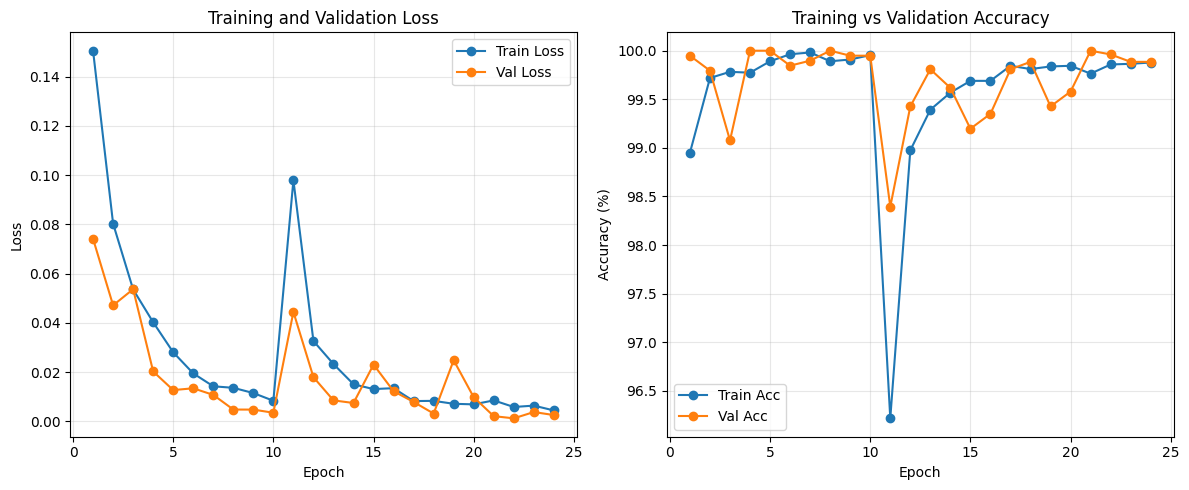

Saved plot to /content/sih_voice_clone/training_curves.png


In [ ]:
def plot_history(history, save_path):
    epochs_range = range(1, len(history['train_loss']) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].plot(epochs_range, history['train_loss'], marker='o', label='Train Loss')
    axes[0].plot(epochs_range, history['val_loss'], marker='o', label='Val Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Training and Validation Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(epochs_range, history['train_acc'], marker='o', label='Train Acc')
    axes[1].plot(epochs_range, history['val_acc'], marker='o', label='Val Acc')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy (%)')
    axes[1].set_title('Training vs Validation Accuracy')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()
    print(f'Saved plot to {save_path}')

# Safely get history from variable or checkpoint
try:
    if 'history' not in globals() or not history['train_loss']:
        if os.path.exists(CKPT_BEST):
            print('Loading history from best checkpoint...')
            ckpt = torch.load(CKPT_BEST, map_location='cpu')
            history = ckpt['history']
        elif os.path.exists(CKPT_LATEST):
            print('Loading history from latest checkpoint...')
            ckpt = torch.load(CKPT_LATEST, map_location='cpu')
            history = ckpt['history']
        else:
            print('No checkpoints found yet. Please finish at least one training epoch.')
            history = None

    if history and history['train_loss']:
        plot_history(history, PLOT_PATH)
except Exception as e:
    print(f'Could not plot history: {e}')

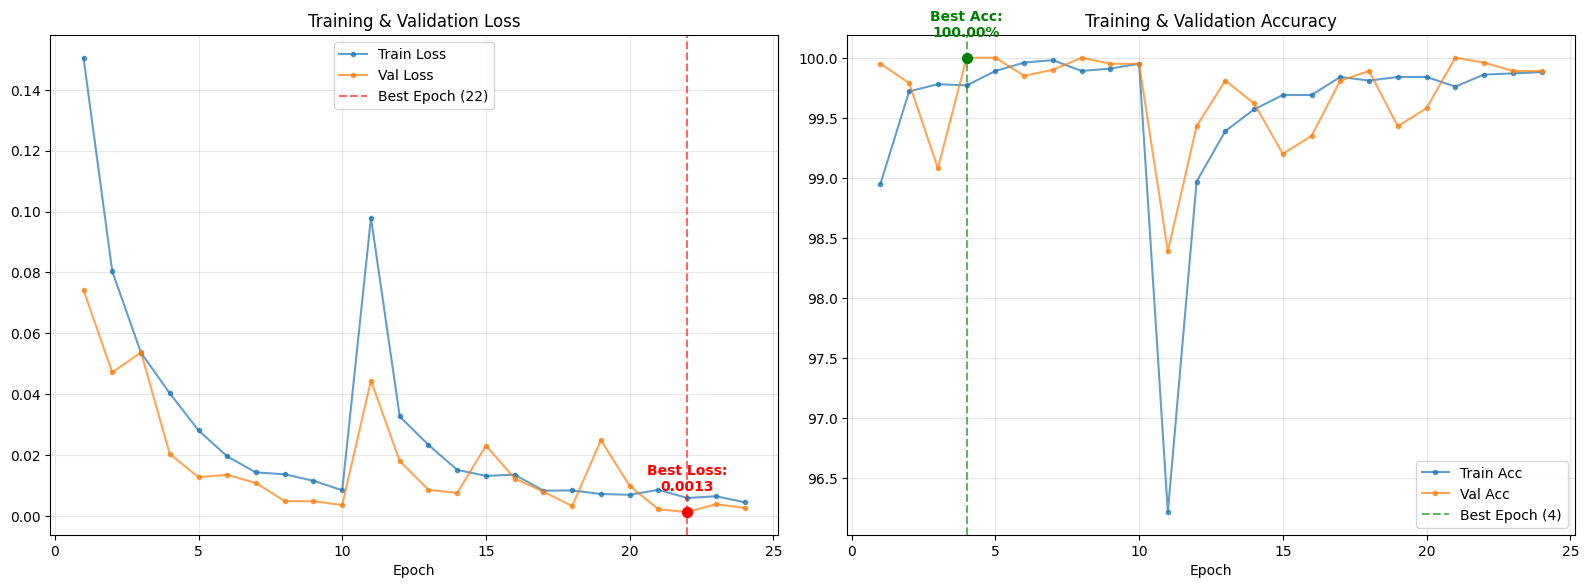

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os

def plot_training_curves(log_path=LOG_CSV_PATH, save_path=os.path.join("/content/", "training_curves.png")):
    df = pd.read_csv(log_path)
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # 1. Loss Plot
    axes[0].plot(df['epoch'], df['train_loss'], marker='o', markersize=3, label='Train Loss', alpha=0.7)
    axes[0].plot(df['epoch'], df['val_loss'], marker='o', markersize=3, label='Val Loss', alpha=0.7)

    # Find Best Loss (Validation)
    best_loss_idx = df['val_loss'].idxmin()
    best_loss_epoch = df.loc[best_loss_idx, 'epoch']
    best_loss_val = df.loc[best_loss_idx, 'val_loss']

    # Add vertical line and point for best loss
    axes[0].axvline(x=best_loss_epoch, color='red', linestyle='--', alpha=0.6, label=f'Best Epoch ({int(best_loss_epoch)})')
    axes[0].scatter(best_loss_epoch, best_loss_val, color='red', s=50, zorder=5)
    axes[0].annotate(f'Best Loss:\n{best_loss_val:.4f}', (best_loss_epoch, best_loss_val),
                     textcoords="offset points", xytext=(0,15), ha='center', color='red', weight='bold')

    axes[0].set_title('Training & Validation Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)
    axes[0].set_xlabel('Epoch')

    # 2. Accuracy Plot
    axes[1].plot(df['epoch'], df['train_acc'], marker='o', markersize=3, label='Train Acc', alpha=0.7)
    axes[1].plot(df['epoch'], df['val_acc'], marker='o', markersize=3, label='Val Acc', alpha=0.7)

    # Find Best Accuracy (Validation)
    best_acc_idx = df['val_acc'].idxmax()
    best_acc_epoch = df.loc[best_acc_idx, 'epoch']
    best_acc_val = df.loc[best_acc_idx, 'val_acc']

    # Add vertical line and point for best accuracy
    axes[1].axvline(x=best_acc_epoch, color='green', linestyle='--', alpha=0.6, label=f'Best Epoch ({int(best_acc_epoch)})')
    axes[1].scatter(best_acc_epoch, best_acc_val, color='green', s=50, zorder=5)
    axes[1].annotate(f'Best Acc:\n{best_acc_val:.2f}%', (best_acc_epoch, best_acc_val),
                     textcoords="offset points", xytext=(0,15), ha='center', color='green', weight='bold')

    axes[1].set_title('Training & Validation Accuracy'); axes[1].legend(); axes[1].grid(alpha=0.3)
    axes[1].set_xlabel('Epoch')

    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()
    return df

df = plot_training_curves()

## 10. Inference — get a risk score for any audio file

In [ ]:
def get_risk_score(model, device, audio_path):
    """
    Returns (risk_score 0-100, label) where risk_score is the probability
    the audio is AI-generated/spoofed.
    """
    waveform, orig_sr = sf.read(audio_path, always_2d=False)
    if waveform.ndim > 1:
        waveform = np.mean(waveform, axis=1)
    if orig_sr != SAMPLE_RATE:
        waveform = librosa.resample(waveform, orig_sr=orig_sr, target_sr=SAMPLE_RATE)

    if len(waveform) >= NUM_SAMPLES:
        waveform = waveform[:NUM_SAMPLES]
    else:
        num_repeats = int(np.ceil(NUM_SAMPLES / len(waveform)))
        waveform = np.tile(waveform, num_repeats)[:NUM_SAMPLES]

    device = next(model.parameters()).device
    waveform_tensor = torch.tensor(waveform.astype(np.float32))  # single 1D waveform, no unsqueeze

    model.eval()
    with torch.no_grad():
        input_values = model.preprocess([waveform_tensor]).to(device)  # preprocess expects a list/batch
        logits = model(input_values)
        probs = F.softmax(logits, dim=1)[0]

    print(f"Logits: {logits}")
    print(f"Probabilities: {probs}")
    spoof_prob = probs[SPOOF_LABEL].item()
    risk_score = round(spoof_prob * 100, 2)
    label = "spoof" if spoof_prob >= 0.5 else "genuine"
    return risk_score, label


# Example usage — load the BEST checkpoint (not latest) for inference
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# best_ckpt = torch.load(CKPT_BEST, map_location=device)
best_ckpt = torch.load(CKPT_LATEST, map_location=device)
inference_model = Wav2Vec2ResNetDetector(num_unfrozen_layers=num_unfrozen_layers).to(device)
inference_model.load_state_dict(best_ckpt["model_state_dict"])
inference_model.eval()
print(f"Loaded best checkpoint from epoch {best_ckpt["epoch"]} with val_acc={best_ckpt["best_val_acc"]:.2f}%")

score, label = get_risk_score(inference_model, device, "/content/fack.wav")
print(f"Risk score: {score}% -> {label}")

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

[transformers] Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     |  | 
-----------------------------+------------+--+-
quantizer.weight_proj.bias   | UNEXPECTED |  | 
project_q.bias               | UNEXPECTED |  | 
quantizer.codevectors        | UNEXPECTED |  | 
quantizer.weight_proj.weight | UNEXPECTED |  | 
project_q.weight             | UNEXPECTED |  | 
project_hid.bias             | UNEXPECTED |  | 
project_hid.weight           | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


wav2vec2: 12 transformer layers total, fine-tuning last 4, rest frozen.
Loaded best checkpoint from epoch 24 with val_acc=100.00%
Logits: tensor([[-4.9937,  4.3109]], device='cuda:0')
Probabilities: tensor([9.0996e-05, 9.9991e-01], device='cuda:0')
Risk score: 99.99% -> spoof


## 12. Evaluate Model Performance on a Test Set

In [ ]:
def get_test_dataloader(dataset_root, batch_size=8, test_split=0.2):
    # Scan all files available
    all_files = scan_dataset(dataset_root)
    if len(all_files) == 0:
        raise RuntimeError(f"No audio files found under {dataset_root}. Check folder structure.")

    # Split all_files into training/validation/test
    # First, split into train+val and test
    train_val_files, test_files = train_test_split(all_files, test_size=test_split, random_state=42, stratify=[f[1] for f in all_files])

    print(f"Total files: {len(all_files)}")
    print(f"Test files: {len(test_files)}")

    test_ds = VoiceDataset(test_files)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=2)
    return test_loader

def evaluate_model_performance(model, dataloader, device):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for waveforms, labels in tqdm(dataloader, desc="Evaluating", unit="batch"):
            waveforms = model.preprocess(waveforms).to(device)
            labels = labels.to(device)

            logits = model(waveforms)
            predictions = logits.argmax(dim=1)

            all_preds.extend(predictions.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds, target_names=["genuine", "spoof"]))

In [ ]:
# Get a separate test dataloader
test_loader = get_test_dataloader(dataset_root, batch_size=batch_size, test_split=0.2)

# Evaluate the inference model
evaluate_model_performance(inference_model, test_loader, device)

Total files: 17444
Test files: 3489


Evaluating:   0%|          | 0/219 [00:00<?, ?batch/s]


Classification Report:
              precision    recall  f1-score   support

     genuine       1.00      1.00      1.00      2375
       spoof       1.00      1.00      1.00      1114

    accuracy                           1.00      3489
   macro avg       1.00      1.00      1.00      3489
weighted avg       1.00      1.00      1.00      3489



Generating Confusion Matrix:   0%|          | 0/219 [00:00<?, ?it/s]

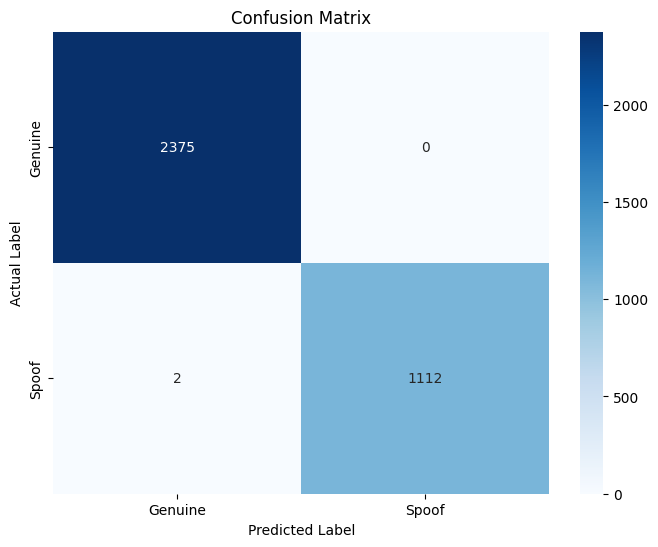

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(model, dataloader, device):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for waveforms, labels in tqdm(dataloader, desc="Generating Confusion Matrix"):
            waveforms = model.preprocess(waveforms).to(device)
            logits = model(waveforms)
            preds = logits.argmax(dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Genuine', 'Spoof'],
                yticklabels=['Genuine', 'Spoof'])
    plt.title('Confusion Matrix')
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.show()

# Run the plotting function using the existing test_loader and inference_model
plot_confusion_matrix(inference_model, test_loader, device)

## 11. Predict

In [ ]:
# Please provide the path to your WAV file here, for example:
audio_path = "/content/fack.wav"
score, label = get_risk_score(inference_model, device, audio_path)
print(f"Risk score: {score}% -> {label}")

Logits: tensor([[-3.6331,  3.2113]], device='cuda:0')
Probabilities: tensor([0.0011, 0.9989], device='cuda:0')
Risk score: 99.89% -> spoof


In [ ]:
# Please provide the path to your WAV file here, for example:
audio_path = "/content/linus-to-musk-DEMO.wav"
score, label = get_risk_score(inference_model, device, audio_path)
print(f"Risk score: {score}% -> {label}")

Logits: tensor([[ 3.7301, -4.1082]], device='cuda:0')
Probabilities: tensor([9.9961e-01, 3.9420e-04], device='cuda:0')
Risk score: 0.04% -> genuine


In [ ]:
from pydub import AudioSegment

# Define your input and output file paths
mp3_file = "/content/linus-original-DEMO.mp3"
wav_file = "linus-original-DEMO.wav"

# Load the MP3 file
sound = AudioSegment.from_mp3(mp3_file)

# Export as WAV
sound.export(wav_file, format="wav")

print("Conversion completed successfully!")

Conversion completed successfully!


In [ ]:
!cp -r "/content/sih_voice_clone" "/content/drive/MyDrive/sih_voice_clone2"

In [ ]:
!sha256sum "/content/sih_voice_clone/checkpoint_best.pt"

ec7856ab91a5fdc55700474efce85bf24ece7af8d36a9d473b6cd2b6745331aa  /content/sih_voice_clone/checkpoint_best.pt


In [ ]:
!sha256sum "/content/drive/MyDrive/sih_voice_clone2/checkpoint_best.pt"

a8193f5cbf6bb20a4d9d8201ad2bc39e1b392fd3323b4d49fd72b85f70211e53  /content/drive/MyDrive/sih_voice_clone2/checkpoint_best.pt


In [ ]:
# !rm -rf "/content/sih_voice_clone"
# !cp -r "/content/drive/MyDrive/sih_voice_clone2" "/content/"
# !mv "/content/sih_voice_clone2" "/content/sih_voice_clone"

In [ ]:
!cp "/content/drive/MyDrive/20260825_084736.wav" "fack.wav"

## 12. Edge Device Ready


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# best_ckpt = torch.load(CKPT_BEST, map_location=device)
best_ckpt = torch.load(CKPT_LATEST, map_location=device)
inference_model = Wav2Vec2ResNetDetector(num_unfrozen_layers=num_unfrozen_layers).to(device)
inference_model.load_state_dict(best_ckpt["model_state_dict"])
inference_model.eval()

In [ ]:
test_loader = get_test_dataloader(dataset_root, batch_size=batch_size, test_split=0.2)

Total files: 17444
Test files: 3489


In [ ]:
import torch
from torch.utils.data import DataLoader

# Create a temporary loader with num_workers=0 to avoid multiprocessing errors when fetching one sample
temp_test_loader = DataLoader(test_loader.dataset, batch_size=1, shuffle=False, num_workers=0)

# Get one sample
waveforms, labels = next(iter(temp_test_loader))

single_waveform = waveforms[0]   # shape: [64000] — raw 1D waveform
single_label = labels[0]

print(f"Waveform shape: {single_waveform.shape}")
print(f"Label: {'Spoof' if single_label == SPOOF_LABEL else 'Genuine'} ({single_label.item()})")

Waveform shape: torch.Size([64000])
Label: Genuine (0)


In [ ]:
single_waveform

tensor([ 0.0450,  0.0219,  0.0009,  ..., -0.0039, -0.0031,  0.0008])

In [ ]:
!pip -q install onnxscript

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 722.0/722.0 kB 20.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.1/19.1 MB 64.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.8/185.8 kB 17.3 MB/s eta 0:00:00


In [ ]:
import torch
import os

# 1. Re-initialize model
inference_model = Wav2Vec2ResNetDetector(num_unfrozen_layers=num_unfrozen_layers).to("cpu")
inference_model.load_state_dict(best_ckpt["model_state_dict"])
inference_model.eval()

# 2. Extract input values once — use model.preprocess() for consistency with train/val/predict
dummy_input_values = inference_model.preprocess([single_waveform]).to("cpu")

# 3. Export using legacy settings with specific flag to avoid Dynamo
with torch.no_grad():
    torch.onnx.export(
        inference_model,
        dummy_input_values,
        "model.onnx",
        input_names=["input_values"],
        output_names=["output"],
        opset_version=17,
        do_constant_folding=True,
        export_params=True,
        training=torch.onnx.TrainingMode.EVAL,
        dynamic_axes={
            "input_values": {0: "batch", 1: "time"},
            "output": {0: "batch"},
        },
        dynamo=False,  # force legacy TorchScript-based tracer — more predictable for this model
    )

if os.path.exists("model.onnx"):
    print("SUCCESS: model.onnx created.")

In [ ]:
import os
print("File exists:", os.path.exists("model.onnx"))
print("File size (MB):", os.path.getsize("model.onnx") / (1024*1024))

File exists: True
File size (MB): 367.3633394241333


In [ ]:
# !python -m onnxruntime.quantization.preprocess --input model.onnx --output model_preprocessed.onnx
!python -m onnxruntime.quantization.preprocess --input model.onnx --output model_preprocessed.onnx --skip_symbolic_shape

usage: preprocess.py [-h] --input INPUT --output OUTPUT
                     [--skip_optimization SKIP_OPTIMIZATION]
                     [--skip_onnx_shape SKIP_ONNX_SHAPE]
                     [--skip_symbolic_shape SKIP_SYMBOLIC_SHAPE]
                     [--auto_merge] [--int_max INT_MAX] [--guess_output_rank]
                     [--verbose VERBOSE] [--save_as_external_data]
                     [--all_tensors_to_one_file]
                     [--external_data_location EXTERNAL_DATA_LOCATION]
                     [--external_data_size_threshold EXTERNAL_DATA_SIZE_THRESHOLD]
preprocess.py: error: argument --skip_symbolic_shape: expected one argument


In [ ]:
!pip -q install onnxruntime

In [ ]:
from onnxruntime.quantization import quantize_dynamic, QuantType

quantize_dynamic(
    model_input="model.onnx",
    model_output="model_quantized.onnx",
    weight_type=QuantType.QInt8
)

In [ ]:
import os
print("File exists:", os.path.exists("/content/model_quantized.onnx"))
print("File size (MB):", os.path.getsize("/content/model_quantized.onnx") / (1024*1024))

File exists: True
File size (MB): 92.59383583068848


In [ ]:
import onnxruntime as ort

sess_options = ort.SessionOptions()
sess_options.intra_op_num_threads = 4
sess_options.execution_mode = ort.ExecutionMode.ORT_SEQUENTIAL
sess_options.graph_optimization_level = ort.GraphOptimizationLevel.ORT_ENABLE_ALL

session = ort.InferenceSession(
    "model_quantized.onnx",
    sess_options=sess_options,
    providers=["CPUExecutionProvider"]
)

# Reuse the same tensor you exported with, converted to numpy
input_values_numpy = dummy_input_values.cpu().numpy()

outputs = session.run(None, {"input_values": input_values_numpy})
print(outputs)

[array([[ 4.248311 , -3.9453912]], dtype=float32)]


In [ ]:
# PyTorch
torch_out = F.softmax(inference_model(dummy_input_values.to(device)), dim=1)

# ONNX quantized — always runs on CPU regardless, so keep dummy_input_values as CPU numpy here
ort_out = session.run(None, {"input_values": dummy_input_values.cpu().numpy()})
ort_probs = torch.softmax(torch.tensor(ort_out[0]), dim=1)

print("PyTorch:", torch_out)
print("ONNX quantized:", ort_probs)

PyTorch: tensor([[9.9986e-01, 1.3849e-04]], device='cuda:0', grad_fn=<SoftmaxBackward0>)
ONNX quantized: tensor([[9.9972e-01, 2.7631e-04]])


In [ ]:
import torch
import torch.nn.functional as F
from tqdm import tqdm   # plain tqdm — no ipywidgets dependency, won't freeze if widgets fail to load
from sklearn.metrics import classification_report, accuracy_score
from itertools import islice
import time
import onnx
import onnxruntime as ort

# --- Sanity check: confirm the quantized model only quantized MatMul, not Conv ---
_m = onnx.load("model_quantized.onnx")
_op_types = set(n.op_type for n in _m.graph.node)
print("Op types in model_quantized.onnx:", _op_types)
if "QLinearConv" in _op_types:
    print("WARNING: Conv layers were quantized — this is likely the slow version. "
          "Re-run quantize_dynamic with op_types_to_quantize=['MatMul'] before continuing.")

# --- Rebuild session from the MatMul-only quantized model ---
sess_options = ort.SessionOptions()
sess_options.execution_mode = ort.ExecutionMode.ORT_SEQUENTIAL
sess_options.graph_optimization_level = ort.GraphOptimizationLevel.ORT_ENABLE_ALL
# don't force intra_op_num_threads here — let ORT auto-detect on Colab's CPU allocation

session = ort.InferenceSession(
    "model_quantized.onnx",
    sess_options=sess_options,
    providers=["CPUExecutionProvider"]
)

# --- Single sample comparison ---
print("\n--- Single Sample Comparison ---")
inference_model.to(device)
torch_out = F.softmax(inference_model(dummy_input_values.to(device)), dim=1)

ort_out = session.run(None, {"input_values": dummy_input_values.cpu().numpy()})
ort_probs = torch.softmax(torch.tensor(ort_out[0]), dim=1)

print("PyTorch output (softmax):", torch_out)
print("ONNX quantized output (softmax):", ort_probs)

# --- Full Evaluation ---
print("\n--- Full Evaluation on Test Dataset ---")

def evaluate_torch_and_onnx_full_dataset(torch_model, onnx_session, dataloader, device, max_batches=None):
    torch_model.eval()
    all_labels = []
    all_torch_preds = []
    all_onnx_preds = []

    diff_count = 0
    total_samples = 0

    with torch.no_grad():
        for idx, (waveforms, labels) in enumerate(tqdm(dataloader, desc="Evaluating Torch and ONNX Models")):
            t0 = time.time()

            input_values = torch_model.preprocess(waveforms).to(device)
            labels = labels.to(device)

            torch_logits = torch_model(input_values)
            torch_predictions = torch_logits.argmax(dim=1)

            ort_out = onnx_session.run(None, {"input_values": input_values.cpu().numpy()})
            onnx_logits = torch.tensor(ort_out[0], device=device)
            onnx_predictions = onnx_logits.argmax(dim=1)

            all_labels.extend(labels.cpu().numpy())
            all_torch_preds.extend(torch_predictions.cpu().numpy())
            all_onnx_preds.extend(onnx_predictions.cpu().numpy())

            for i in range(len(labels)):
                if torch_predictions[i] != onnx_predictions[i]:
                    diff_count += 1
                total_samples += 1

            elapsed = time.time() - t0
            print(f"batch {idx}: {elapsed:.2f}s", flush=True)

            if max_batches is not None and idx + 1 >= max_batches:
                break

    present_labels = sorted(set(all_labels) | set(all_torch_preds) | set(all_onnx_preds))
    target_names = ["genuine", "spoof"]
    names_for_report = [target_names[i] for i in present_labels]

    print("\nPyTorch Model Performance:")
    print(classification_report(all_labels, all_torch_preds, labels=present_labels, target_names=names_for_report))
    print(f"PyTorch Accuracy: {accuracy_score(all_labels, all_torch_preds):.4f}")

    print("\nONNX Quantized Model Performance:")
    print(classification_report(all_labels, all_onnx_preds, labels=present_labels, target_names=names_for_report))
    print(f"ONNX Quantized Accuracy: {accuracy_score(all_labels, all_onnx_preds):.4f}")

    print(f"\nNumber of samples where PyTorch and ONNX predictions differed: {diff_count} out of {total_samples}")
    if total_samples > 0:
        print(f"Percentage of differing predictions: {diff_count / total_samples * 100:.2f}%")

# Quick check on first 5 batches only
evaluate_torch_and_onnx_full_dataset(inference_model, session, test_loader, device, max_batches=5)

# Once quick check looks fast and reasonable, run the full set:
# evaluate_torch_and_onnx_full_dataset(inference_model, session, test_loader, device)